# MNIST Classification Demo

Demonstrates all three classifiers - Random Forest, Feed-Forward NN, and CNN - through the unified `MnistClassifier` interface.

## 1. Setup and Data Loading

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mnist_classifier import MnistClassifier

In [7]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data.astype(np.float32), mnist.target.astype(int)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (60000, 784), Test: (10000, 784)


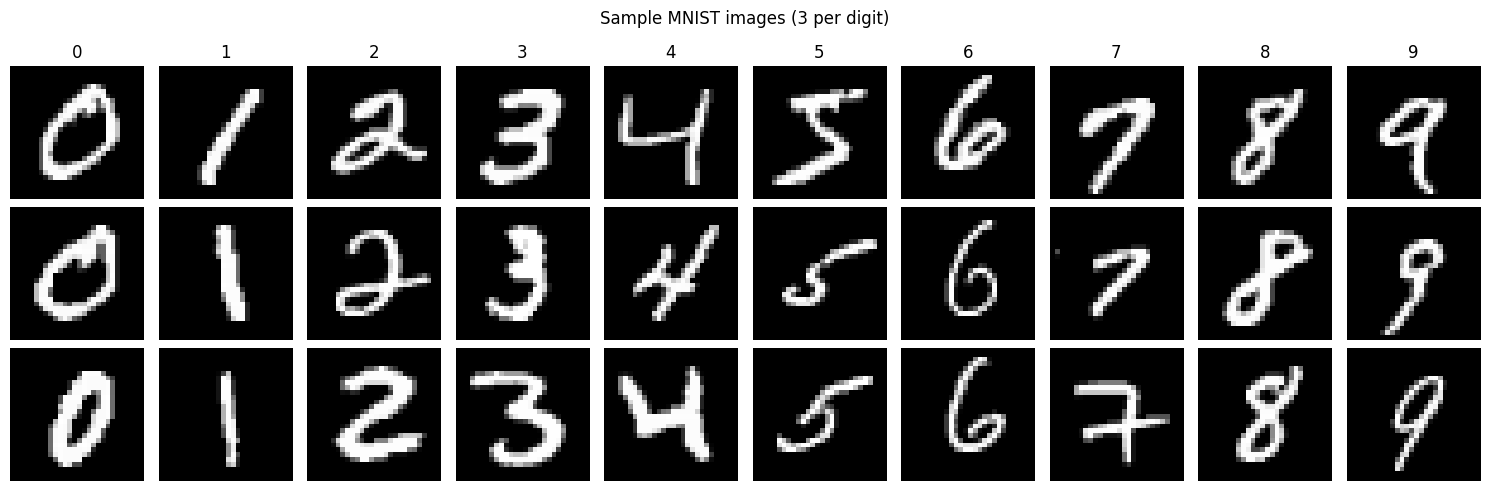

In [8]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for digit in range(10):
    idxs = np.where(y_train == digit)[0][:3]
    for row, idx in enumerate(idxs):
        axes[row, digit].imshow(X_train[idx].reshape(28, 28), cmap="gray")
        axes[row, digit].axis("off")
        if row == 0:
            axes[row, digit].set_title(str(digit))
plt.suptitle("Sample MNIST images (3 per digit)")
plt.tight_layout()
plt.show()

In [9]:
unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution (train):")
for cls, cnt in zip(unique, counts):
    print(f"  Digit {cls}: {cnt} samples")

Class distribution (train):
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


## 2. Train Models

In [10]:
algos = ["rf", "ffnn", "cnn"]
results = {}

for algo in algos:
    print(f"\n{'='*40}")
    print(f"Training: {algo.upper()}")
    print('='*40)
    clf = MnistClassifier(algo)

    t0 = time.time()
    clf.train(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    preds = clf.predict(X_test)
    infer_time = time.time() - t0

    acc = accuracy_score(y_test, preds)
    results[algo] = {
        "clf": clf,
        "preds": preds,
        "accuracy": acc,
        "train_time": train_time,
        "infer_time": infer_time,
    }
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  Train time:      {train_time:.1f}s")
    print(f"  Inference time:  {infer_time:.3f}s")


Training: RF
RandomForest training completed.
  Accuracy:        0.9689
  Train time:      8.4s
  Inference time:  0.122s

Training: FFNN
Epoch 1/20 - loss: 0.2626
Epoch 2/20 - loss: 0.1210
Epoch 3/20 - loss: 0.0933
Epoch 4/20 - loss: 0.0821
Epoch 5/20 - loss: 0.0742
Epoch 6/20 - loss: 0.0654
Epoch 7/20 - loss: 0.0583
Epoch 8/20 - loss: 0.0570
Epoch 9/20 - loss: 0.0524
Epoch 10/20 - loss: 0.0505
Epoch 11/20 - loss: 0.0496
Epoch 12/20 - loss: 0.0451
Epoch 13/20 - loss: 0.0445
Epoch 14/20 - loss: 0.0451
Epoch 15/20 - loss: 0.0417
Epoch 16/20 - loss: 0.0408
Epoch 17/20 - loss: 0.0406
Epoch 18/20 - loss: 0.0402
Epoch 19/20 - loss: 0.0393
Epoch 20/20 - loss: 0.0390
  Accuracy:        0.9822
  Train time:      98.4s
  Inference time:  0.159s

Training: CNN
Epoch 1/15 - loss: 0.2774
Epoch 2/15 - loss: 0.0696
Epoch 3/15 - loss: 0.0488
Epoch 4/15 - loss: 0.0382
Epoch 5/15 - loss: 0.0313
Epoch 6/15 - loss: 0.0251
Epoch 7/15 - loss: 0.0206
Epoch 8/15 - loss: 0.0166
Epoch 9/15 - loss: 0.0147
Epoc

## 3. Evaluation

In [11]:
print(f"{'Algorithm':<12} {'Accuracy':>10} {'Train (s)':>12} {'Infer (s)':>12}")
print("-" * 48)
for algo, r in results.items():
    print(f"{algo.upper():<12} {r['accuracy']:>10.4f} {r['train_time']:>12.1f} {r['infer_time']:>12.3f}")

Algorithm      Accuracy    Train (s)    Infer (s)
------------------------------------------------
RF               0.9689          8.4        0.122
FFNN             0.9822         98.4        0.159
CNN              0.9943        440.3        2.030


In [12]:
for algo, r in results.items():
    print(f"\n--- {algo.upper()} Classification Report ---")
    print(classification_report(y_test, r["preds"], digits=4))


--- RF Classification Report ---
              precision    recall  f1-score   support

           0     0.9709    0.9878    0.9793       980
           1     0.9894    0.9894    0.9894      1135
           2     0.9579    0.9709    0.9644      1032
           3     0.9632    0.9594    0.9613      1010
           4     0.9724    0.9695    0.9709       982
           5     0.9762    0.9652    0.9707       892
           6     0.9730    0.9791    0.9761       958
           7     0.9735    0.9640    0.9687      1028
           8     0.9587    0.9528    0.9557       974
           9     0.9522    0.9485    0.9503      1009

    accuracy                         0.9689     10000
   macro avg     0.9688    0.9687    0.9687     10000
weighted avg     0.9689    0.9689    0.9689     10000


--- FFNN Classification Report ---
              precision    recall  f1-score   support

           0     0.9878    0.9918    0.9898       980
           1     0.9877    0.9938    0.9908      1135
        

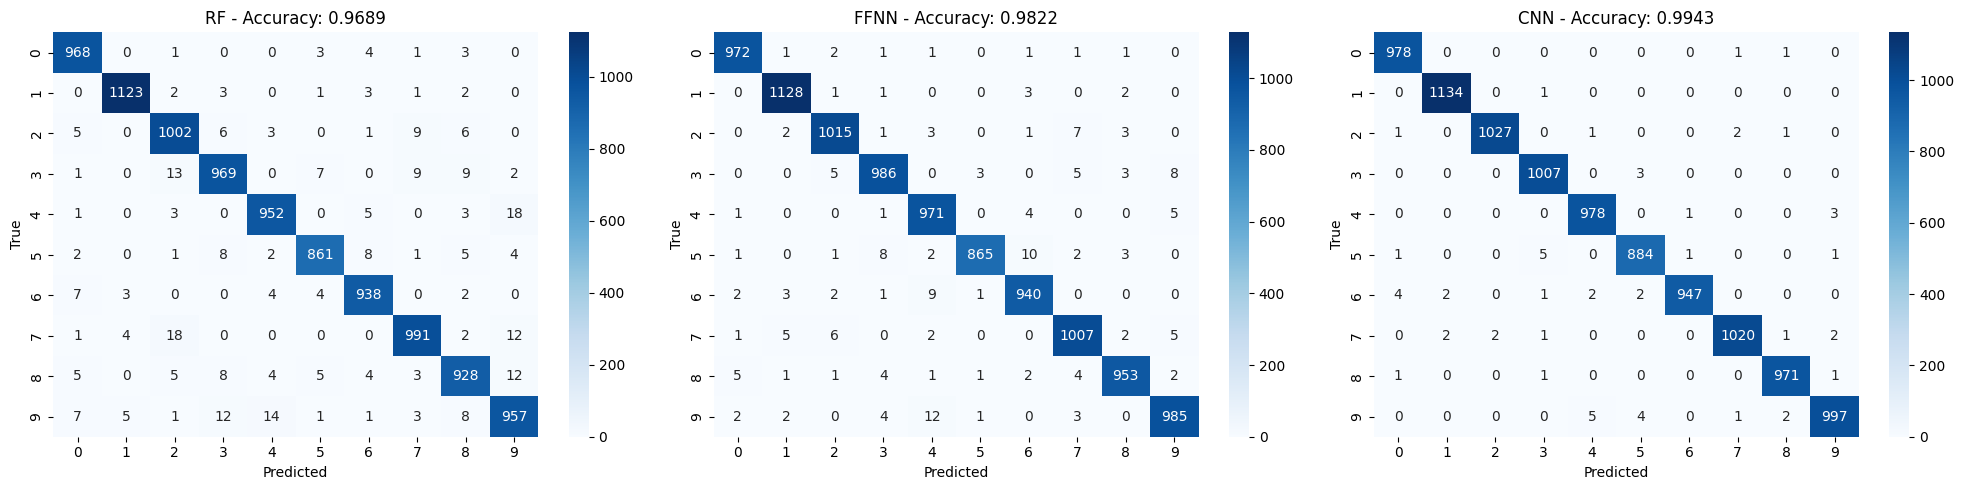

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (algo, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(f"{algo.upper()} - Accuracy: {r['accuracy']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

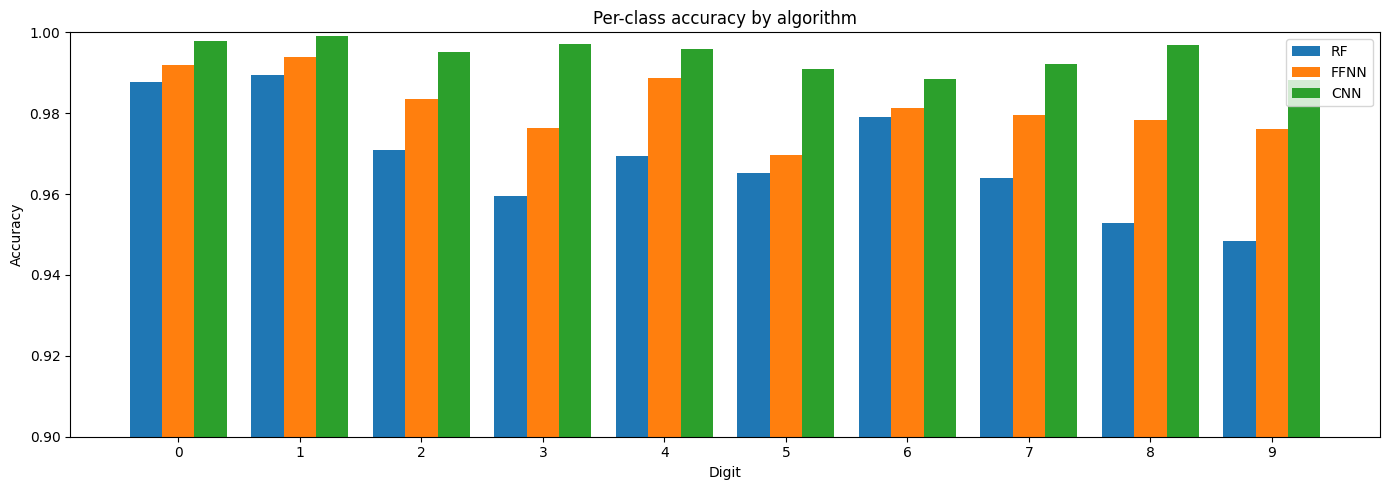

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(10)
n = len(results)
width = 0.8 / n
for i, (algo, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    ax.bar(x + i * width, per_class_acc, width, label=algo.upper())
ax.set_xticks(x + width * (n - 1) / 2)
ax.set_xticklabels(range(10))
ax.set_xlabel("Digit")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.9, 1.0)
ax.set_title("Per-class accuracy by algorithm")
ax.legend()
plt.tight_layout()
plt.show()

## 4. OOP Interface Demonstration

In [15]:
from interface import MnistClassifierInterface

for algo in algos:
    clf = MnistClassifier(algo)
    is_impl = isinstance(clf._classifier, MnistClassifierInterface)
    print(f"{algo.upper()} implements MnistClassifierInterface: {is_impl}")

RF implements MnistClassifierInterface: True
FFNN implements MnistClassifierInterface: True
CNN implements MnistClassifierInterface: True


In [16]:
sample = X_test[:5]
print(f"Input shape: {sample.shape}")
for algo in algos:
    print()
    clf = MnistClassifier(algo)
    clf.train(X_train[:1000], y_train[:1000])
    preds = clf.predict(sample)
    print(f"{algo.upper()} output: {preds}  shape={preds.shape}  dtype={preds.dtype}")

Input shape: (5, 784)

RandomForest training completed.
RF output: [7 2 1 0 4]  shape=(5,)  dtype=int64

Epoch 1/20 - loss: 1.8948
Epoch 2/20 - loss: 1.0689
Epoch 3/20 - loss: 0.5558
Epoch 4/20 - loss: 0.3050
Epoch 5/20 - loss: 0.1820
Epoch 6/20 - loss: 0.1020
Epoch 7/20 - loss: 0.0693
Epoch 8/20 - loss: 0.0453
Epoch 9/20 - loss: 0.0291
Epoch 10/20 - loss: 0.0210
Epoch 11/20 - loss: 0.0126
Epoch 12/20 - loss: 0.0109
Epoch 13/20 - loss: 0.0109
Epoch 14/20 - loss: 0.0073
Epoch 15/20 - loss: 0.0065
Epoch 16/20 - loss: 0.0076
Epoch 17/20 - loss: 0.0059
Epoch 18/20 - loss: 0.0049
Epoch 19/20 - loss: 0.0040
Epoch 20/20 - loss: 0.0045
FFNN output: [7 6 1 0 4]  shape=(5,)  dtype=int64

Epoch 1/15 - loss: 2.2828
Epoch 2/15 - loss: 2.0395
Epoch 3/15 - loss: 1.4299
Epoch 4/15 - loss: 0.9109
Epoch 5/15 - loss: 0.6801
Epoch 6/15 - loss: 0.5883
Epoch 7/15 - loss: 0.4725
Epoch 8/15 - loss: 0.3911
Epoch 9/15 - loss: 0.3516
Epoch 10/15 - loss: 0.3247
Epoch 11/15 - loss: 0.3112
Epoch 12/15 - loss: 0.257

## 5. Edge Cases

### 5.1 Invalid algorithm

In [17]:
try:
    clf = MnistClassifier("svm")
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Unsupported algorithm 'svm'. Supported algorithms: ['rf', 'ffnn', 'cnn']


### 5.2 Predict before train

In [18]:
for algo in algos:
    clf = MnistClassifier(algo)
    try:
        clf.predict(X_test[:5])
        print(f"{algo} should have raised RuntimeError")
    except RuntimeError as e:
        print(f"{algo.upper()} RuntimeError: {e}")

RF RuntimeError: Model is not trained yet. Call train() before predict().
FFNN RuntimeError: Model is not trained yet. Call train() before predict().
CNN RuntimeError: Model is not trained yet. Call train() before predict().


### 5.3 Single sample prediction (batch size 1)

In [19]:
single = X_test[[0]]  # shape (1, 784)
true_label = y_test[0]
print(f"Input shape: {single.shape}, True label: {true_label}")

for algo, r in results.items():
    pred = r["clf"].predict(single)
    print(f"{algo.upper()} prediction: {pred[0]}  (correct: {pred[0] == true_label})")

Input shape: (1, 784), True label: 7
RF prediction: 7  (correct: True)
FFNN prediction: 7  (correct: True)
CNN prediction: 7  (correct: True)


### 5.4 All-zero image (blank canvas)

In [20]:
# No crash - may predict any class since blank images are out-of-distribution
blank = np.zeros((1, 784), dtype=np.float32)
print("Predictions on a blank (all-zero) image:")
for algo, r in results.items():
    pred = r["clf"].predict(blank)
    print(f"  {algo.upper()}: {pred[0]}")

Predictions on a blank (all-zero) image:
  RF: 7
  FFNN: 1
  CNN: 1


### 5.5 All-white image (max pixel values)

In [21]:
# No crash - out-of-distribution input handled gracefully
white = np.full((1, 784), 255.0, dtype=np.float32)
print("Predictions on an all-white (255) image:")
for algo, r in results.items():
    pred = r["clf"].predict(white)
    print(f"  {algo.upper()}: {pred[0]}")

Predictions on an all-white (255) image:
  RF: 0
  FFNN: 8
  CNN: 1


### 5.6 Random noise image

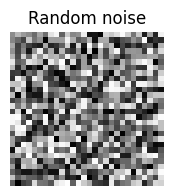

Predictions on random noise:
  RF: 8
  FFNN: 8
  CNN: 2


In [22]:
# No crash - models still produce a prediction, but it's meaningless

rng = np.random.RandomState(0)
noise = rng.rand(1, 784).astype(np.float32) * 255

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax.imshow(noise.reshape(28, 28), cmap="gray")
ax.set_title("Random noise")
ax.axis("off")
plt.show()

print("Predictions on random noise:")
for algo, r in results.items():
    pred = r["clf"].predict(noise)
    print(f"  {algo.upper()}: {pred[0]}")

### 5.7 Hyperparameter forwarding via kwargs

In [23]:
clf_rf = MnistClassifier("rf", n_estimators=50, max_depth=10)
print(f"RF n_estimators: {clf_rf._classifier._model.n_estimators}")  # 50
print(f"RF max_depth:    {clf_rf._classifier._model.max_depth}")     # 10

clf_nn = MnistClassifier("ffnn", epochs=2, batch_size=256)
print(f"FFNN epochs:     {clf_nn._classifier._epochs}")              # 2
print(f"FFNN batch_size: {clf_nn._classifier._batch_size}")          # 256

clf_cnn = MnistClassifier("cnn", epochs=3, dropout=0.5)
print(f"CNN epochs:      {clf_cnn._classifier._epochs}")             # 3
print(f"CNN dropout:     {clf_cnn._classifier._net.classifier[3].p}")  # 0.5

RF n_estimators: 50
RF max_depth:    10
FFNN epochs:     2
FFNN batch_size: 256
CNN epochs:      3
CNN dropout:     0.5


### 5.8 Batch of identical images

In [24]:
# 10 copies of the same image should all get the same prediction
repeated = np.tile(X_test[0], (10, 1))  # shape (10, 784)
print(f"Input: 10 copies of the same image, shape {repeated.shape}")
for algo, r in results.items():
    preds = r["clf"].predict(repeated)
    all_same = len(set(preds)) == 1
    print(f"  {algo.upper()}: {preds} - all same: {all_same}")

Input: 10 copies of the same image, shape (10, 784)
  RF: [7 7 7 7 7 7 7 7 7 7] - all same: True
  FFNN: [7 7 7 7 7 7 7 7 7 7] - all same: True
  CNN: [7 7 7 7 7 7 7 7 7 7] - all same: True


## 6. Custom Handwritten Images

Testing classifiers on hand-drawn digit photos (`test_1.png` ... `test_9.png`) that were not part of the MNIST dataset. Images are automatically converted to 28x28 grayscale and inverted to match MNIST format (white digit on black background).

In [36]:
import glob
import os
from PIL import Image, ImageFilter

# Auto-discover test_*.png files and extract digit from filename
test_files = sorted(glob.glob("test_data/test_*.png"))
test_images = {}
for path in test_files:
    digit = int(os.path.basename(path).split("_")[1].split(".")[0])
    test_images[digit] = path

print(f"Found {len(test_images)} test images: digits {list(test_images.keys())}")


def preprocess_for_mnist(path):
    """Convert any image to MNIST-compatible 28x28 format.

    Steps mirror how MNIST was originally created:
      1. Grayscale + invert (white digit on black background)
      2. Binarize to remove noise from photo background
      3. Crop to bounding box of the digit (remove empty margins)
      4. Dilate to thicken thin strokes (pen/pencil -> marker-like)
      5. Fit into 20x20 box preserving aspect ratio (MNIST standard)
      6. Center in 28x28 frame using center of mass
      7. Light Gaussian blur (MNIST digits have soft edges)
    """
    # 1. Load as grayscale
    img = Image.open(path).convert("L")
    pixels = np.array(img, dtype=np.float32)

    # Invert if light background (paper photo)
    if pixels.mean() > 127:
        pixels = 255.0 - pixels

    # 2. Binarize — threshold to remove noise
    threshold = 50
    pixels[pixels < threshold] = 0

    # 3. Crop to bounding box of non-zero pixels
    coords = np.argwhere(pixels > 0)
    if len(coords) == 0:
        return np.zeros(784, dtype=np.float32)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    cropped = pixels[y_min:y_max + 1, x_min:x_max + 1]

    # 4. Dilate to thicken thin strokes
    cropped_img = Image.fromarray(cropped.astype(np.uint8))
    # Scale dilation iterations based on image size
    dilate_iter = max(1, min(cropped_img.width, cropped_img.height) // 30)
    for _ in range(dilate_iter):
        cropped_img = cropped_img.filter(ImageFilter.MaxFilter(3))

    # 5. Fit into 20x20 preserving aspect ratio (MNIST standard)
    w, h = cropped_img.size
    scale = 20.0 / max(w, h)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cropped_img.resize((new_w, new_h), Image.LANCZOS)

    # 6. Center in 28x28 using center of mass
    canvas = Image.new("L", (28, 28), 0)
    arr = np.array(resized, dtype=np.float32)
    # Center of mass offset
    cy, cx = np.where(arr > 0)
    if len(cy) > 0:
        com_y = int(np.mean(cy))
        com_x = int(np.mean(cx))
        offset_x = 14 - com_x - (28 - new_w) // 2
        offset_y = 14 - com_y - (28 - new_h) // 2
        paste_x = (28 - new_w) // 2 + offset_x
        paste_y = (28 - new_h) // 2 + offset_y
        # Clamp to canvas bounds
        paste_x = max(0, min(paste_x, 28 - new_w))
        paste_y = max(0, min(paste_y, 28 - new_h))
    else:
        paste_x = (28 - new_w) // 2
        paste_y = (28 - new_h) // 2
    canvas.paste(resized, (paste_x, paste_y))

    # 7. Light Gaussian blur (MNIST has soft edges)
    canvas = canvas.filter(ImageFilter.GaussianBlur(radius=0.8))

    return np.array(canvas, dtype=np.float32).reshape(784)

Found 9 test images: digits [1, 2, 3, 4, 5, 6, 7, 8, 9]


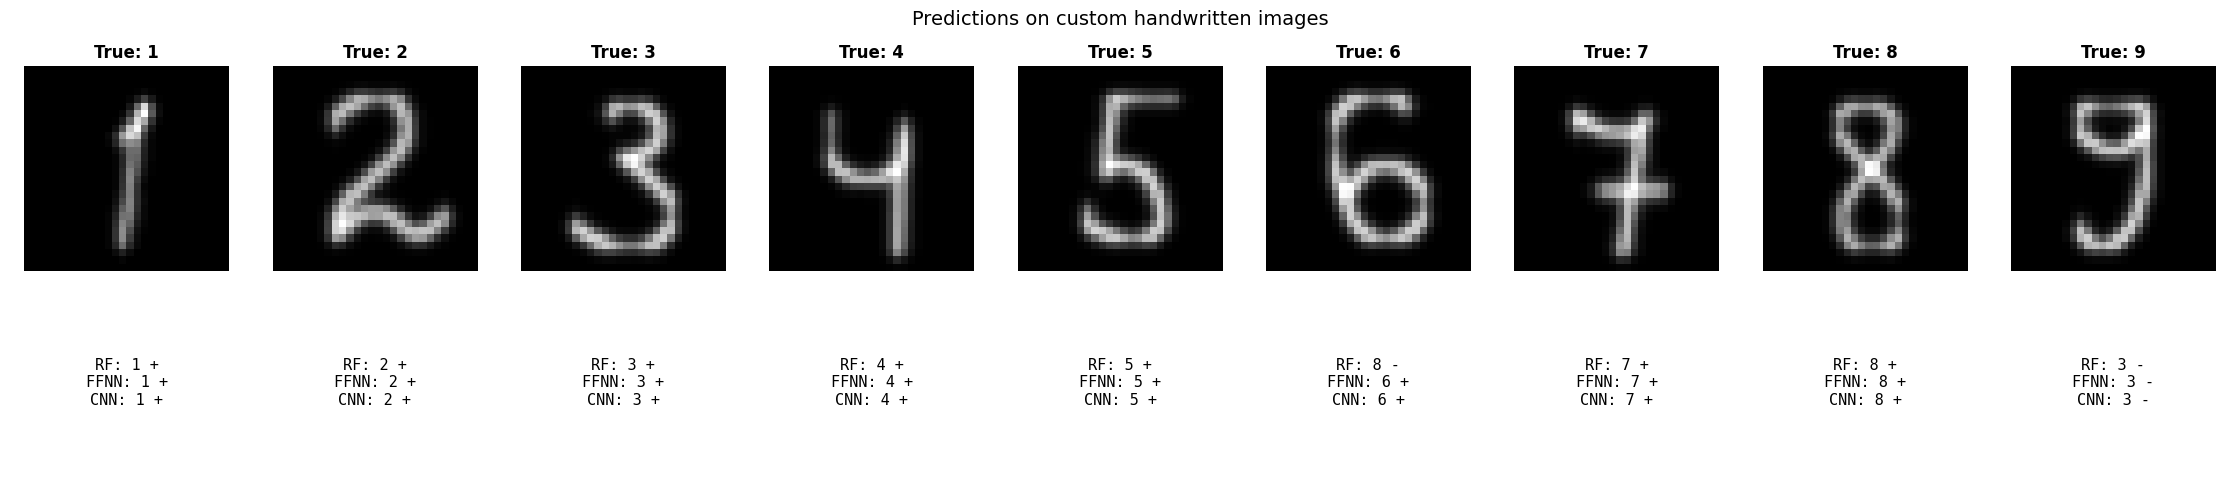

In [37]:
n_images = len(test_images)
fig, axes = plt.subplots(2, n_images, figsize=(n_images * 2.5, 5))

for col, (true_digit, path) in enumerate(test_images.items()):
    flat = preprocess_for_mnist(path)
    pixels_28 = flat.reshape(28, 28)

    # Show the preprocessed image
    axes[0, col].imshow(pixels_28, cmap="gray")
    axes[0, col].set_title(f"True: {true_digit}", fontsize=12, fontweight="bold")
    axes[0, col].axis("off")

    # Predictions from each trained model
    pred_lines = []
    for algo, r in results.items():
        pred = r["clf"].predict(flat.reshape(1, 784))[0]
        mark = "+" if pred == true_digit else "-"
        pred_lines.append(f"{algo.upper()}: {pred} {mark}")

    axes[1, col].axis("off")
    axes[1, col].text(0.5, 0.5, "\n".join(pred_lines),
                      ha="center", va="center", fontsize=11, family="monospace",
                      transform=axes[1, col].transAxes)

plt.suptitle("Predictions on custom handwritten images", fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
print("Accuracy on custom handwritten images:")
print("-" * 40)
for algo, r in results.items():
    correct = 0
    for true_digit, path in test_images.items():
        flat = preprocess_for_mnist(path)
        pred = r["clf"].predict(flat.reshape(1, 784))[0]
        correct += int(pred == true_digit)
    print(f"  {algo.upper()}: {correct}/{len(test_images)}")

Accuracy on custom handwritten images:
----------------------------------------
  RF: 7/9
  FFNN: 8/9
  CNN: 8/9
